In [216]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
import seaborn as sns

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import gensim.downloader as api

In [188]:
me = (-0.3, 0.5)
person2 = (-0.1, 0.8)
person3 = (0.5, -0.3)
person4 = (0.5, 0.3)

In [189]:
vectors = [
    me + ('r', 'me'),
    person2 + ('b', 'person1'),
    person3 + ('g', 'person2'),
    person4 + ('y', 'person3')
]

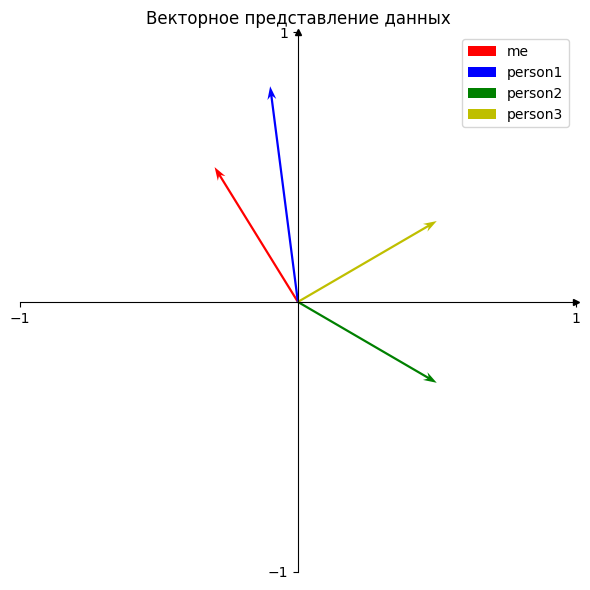

In [132]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=5)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=5)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks([-1, 1])
ax.set_yticks([-1, 1])

for dx, dy, color, label in vectors:
    ax.quiver(0, 0, dx, dy, angles='xy', scale_units='xy', scale=1, 
              color=color, linewidth=0.5, label=label, headwidth=4,
              headlength=6, width=0.004)

ax.legend()

plt.title('Векторное представление данных')
plt.tight_layout()
plt.show()

Мы можем представить трех людей(их черты, предпочтения, увлечение или т.п) \
После чего отобразить их в векторном пространстве. 

Представим, что вы person1, то мы сможем увидить кто находится ближе к вам.

___

---

Косинусово сходство. Что это?

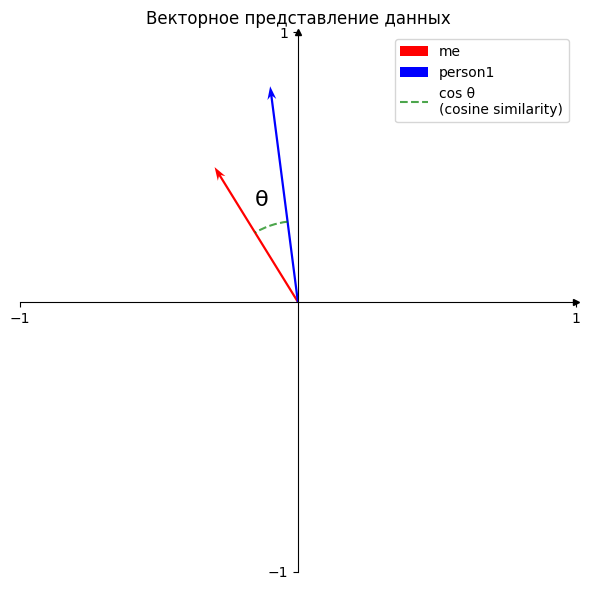

In [238]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=5)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=5)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks([-1, 1])
ax.set_yticks([-1, 1])

for dx, dy, color, label in vectors[:2]:
    ax.quiver(0, 0, dx, dy, angles='xy', scale_units='xy', scale=1, 
              color=color, linewidth=0.5, label=label, headwidth=4,
              headlength=6, width=0.004)

v1 = np.array([vectors[0][0], vectors[0][1]])
v2 = np.array([vectors[1][0], vectors[1][1]])

cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle_rad = np.arccos(np.clip(cos_angle, -1, 1))
angle_deg = np.degrees(angle_rad)

angle1 = np.degrees(np.arctan2(v1[1], v1[0]))
angle2 = np.degrees(np.arctan2(v2[1], v2[0]))

theta1, theta2 = angle2, angle1
radius = 0.3

arc = Arc((0, 0), 2*radius, 2*radius, theta1=theta1, theta2=theta2,
          edgecolor='g', linewidth=1.5, linestyle='--', alpha=0.7)
ax.add_patch(arc)

mid_angle = np.radians((angle1 + angle2) / 2)

text_radius = 0.4

text_x = text_radius * np.cos(mid_angle)
text_y = text_radius * np.sin(mid_angle)

ax.text(text_x, text_y, f'θ', 
        fontsize=16, 
        ha='center', 
        va='center')
ax.plot([], [], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label=f'cos θ \n(cosine similarity)')
ax.legend()

plt.title('Векторное представление данных')
plt.tight_layout()
plt.show()

Косинусное сходство(Cosine Similarity) измеряет угол между двумя векторами в многомерном пространстве. 

$$
\text{similarity} =  \frac{A \cdot B}{||A|| ||B||} = \frac{\sum^n_{i=1} A_i \times B_i}{\sqrt{\sum^n_{i=1}(A_i)^2} \times \sqrt{\sum^n_{i=1}(B_i)^2}}
$$

Где:
- $A \cdot B$ — скалярное произведение (dot product)
- $||A||$ — евклидова норма (длина) вектора A
- $||B||$ — евклидова норма (длина) вектора B

In [212]:
dot = sum([a * b for a, b in zip(me, person2)])

norm_a = sum([a ** 2 for a in me]) ** 0.5
norm_b = sum([a ** 2 for a in person2]) ** 0.5

result = dot / (norm_a * norm_b)

In [213]:
result

0.9146866040947618

In [214]:
round(result, 2)

0.91

Можем сравнить. У нас получился тот же результат, что и ниже

___

---

In [133]:
vectors = np.array([person1, person2, person3, person4])

similarity = cosine_similarity(vectors)

In [134]:
vectors

array([[-0.3,  0.5],
       [-0.1,  0.8],
       [ 0.5, -0.3],
       [ 0.5,  0.3]])

In [135]:
similarity

array([[ 1.        ,  0.9146866 , -0.88235294,  0.        ],
       [ 0.9146866 ,  1.        , -0.61688166,  0.40416385],
       [-0.88235294, -0.61688166,  1.        ,  0.47058824],
       [ 0.        ,  0.40416385,  0.47058824,  1.        ]])

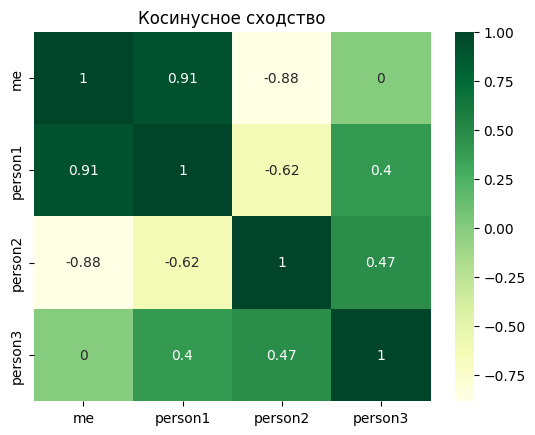

In [136]:
labels = ['me', 'person1', 'person2', 'person3']

sns.heatmap(similarity, cmap='YlGn', annot=True, 
           xticklabels=labels, yticklabels=labels)
plt.title('Косинусное сходство')
plt.show()

Но не на графиках все основано. Мы вычисляем сходство с помощью `cosine similarity`

Значения от -1 до 1 
- 1 = одинаковые направления 
- 0 = перпендикулярны 
- -1 = противоположные направления 

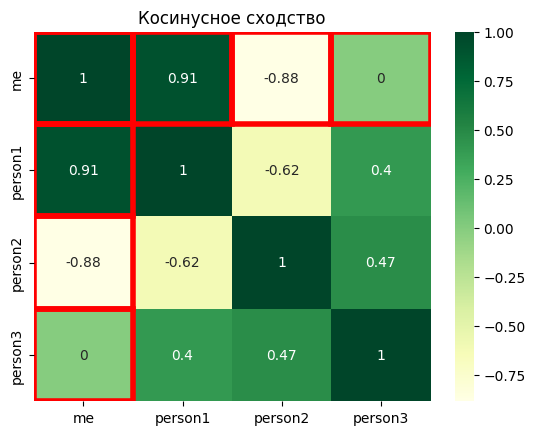

In [137]:
labels = ['me', 'person1', 'person2', 'person3']

ax = sns.heatmap(similarity, cmap='YlGn', annot=True, 
                 xticklabels=labels, yticklabels=labels)
plt.title('Косинусное сходство')

for col in range(len(labels)):
    rect = Rectangle((col, 0), 1, 1, fill=False, edgecolor='red', linewidth=4)
    ax.add_patch(rect)

for row in range(len(labels)):
    rect = Rectangle((0, row), 1, 1, fill=False, edgecolor='red', linewidth=4)
    ax.add_patch(rect)

plt.show()

А теперь конкретно по нашему случаю. Для нас(me), мы видим, что:
- человек 1 это то самое сходство, которое мы видили на графике. Этот человек больше всего похож на нас
- человек 2 это полная противоположность нам, с коэфициентом близким к -1.
- и человек 3, с коэфициентом 0. Эти два человека никак не связаны между собой

Ограничения \
Все мы понимаем, что мы можем отобразить 2d(0.1, 0.2) вектор на графике и даже 3d(0.1, 0.2, 0.3). Но мы не можем изобразить nd. Как раз в этом случае, косинусово сходство справляется очень великолепно

___

---

Аналогии 

Слова объясняют любую нагрузку

In [184]:
man = np.array([0.8, -0.3, 0.7, -0.4, 0.15, 0.33])
woman = np.array([-0.8, -0.62, 0.33, -0.1, 0.88, 0.265])

mw = man + woman
love = np.array([0.15, -1, 1, -0.5,  1, 0.45])

general = np.array([
    man,
    woman,
    mw,
    love
])

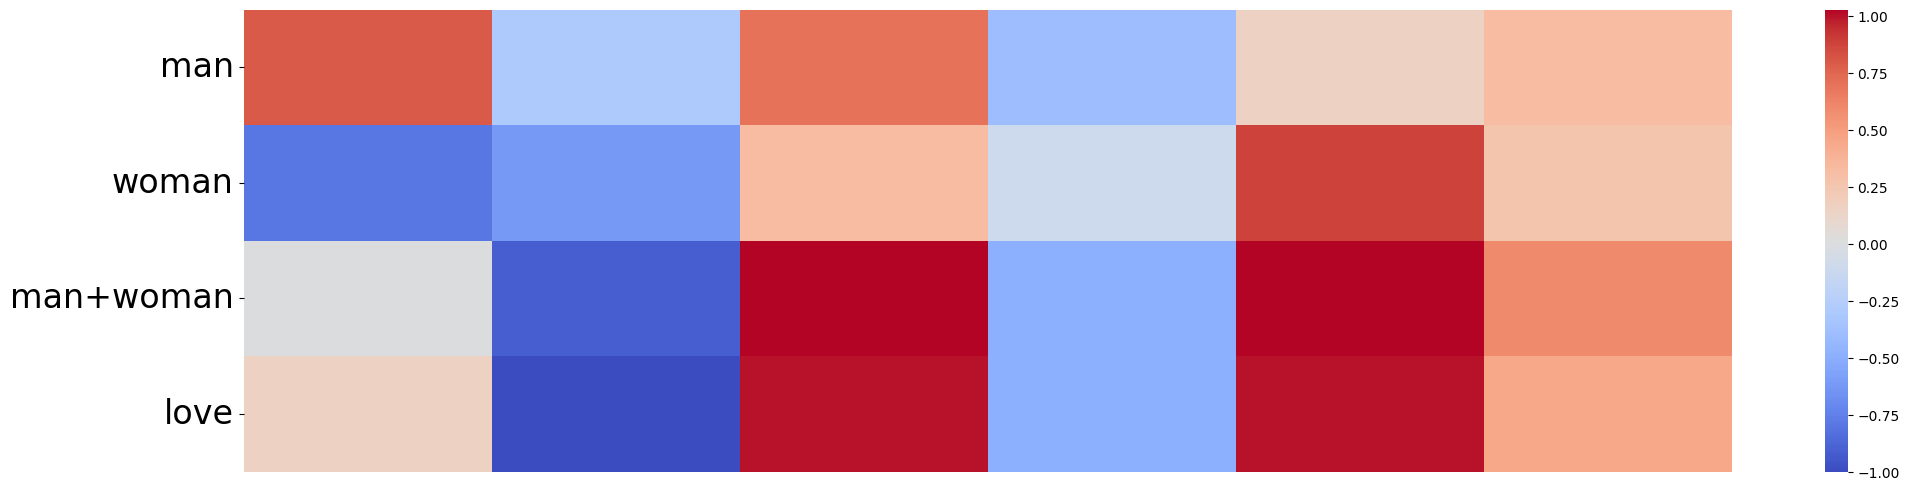

In [185]:
naming = ['man', 'woman', 'man+woman', 'love']

plt.figure(figsize=(24, 6))

sns.heatmap(general, cmap='coolwarm', 
            yticklabels=naming, xticklabels=False)
plt.yticks(rotation=0, fontsize=24)
plt.show()

Мы можем складывать и вычитать вектора. Манипулируя ими, получая интересные результаты.

Как в нашем простом примере. Если прибавить мужчину к женщине, мы примерно получим любовь.

Но перейдем к более популярному примеру индустрии

___

---

In [176]:
model = api.load('glove-wiki-gigaword-50')

king = model['king']
man = model['man']
woman = model['woman']
kmw = king - man + woman
queen = model['queen']

total = np.array([
    king, 
    man,
    woman,
    kmw,
    queen
])

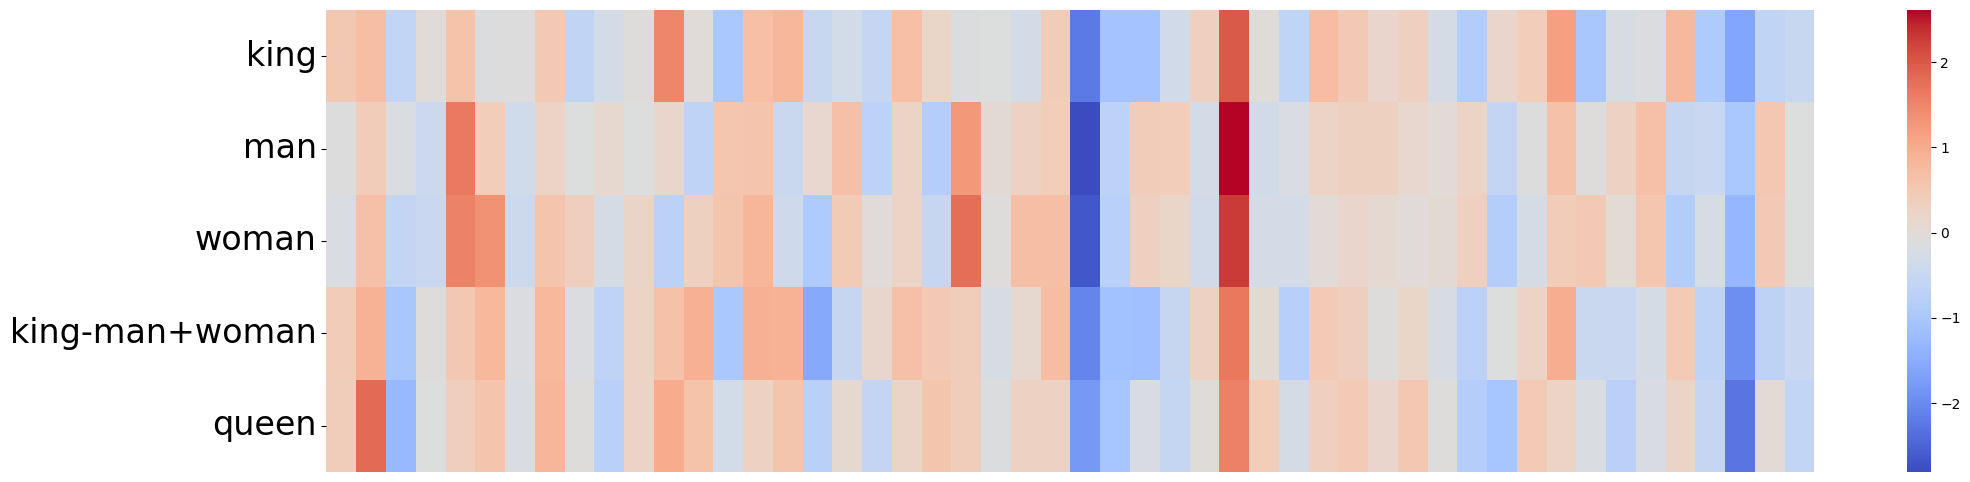

In [177]:
naming = ['king', 'man', 'woman', 'king-man+woman', 'queen']

plt.figure(figsize=(24, 6))

sns.heatmap(total, cmap='coolwarm', 
            yticklabels=naming, xticklabels=False)
plt.yticks(rotation=0, fontsize=24)
plt.show()

Король - мужчина + женщина: при такой операции, мы примерно получим королеву.

Мы использовали модель обученную на википедии. И можем сравнить как наша операция примерно похожа на вектор королева.